In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib
# Since we are importing matplotlib as a whole, we set the backend to 'Agg'
matplotlib.use('Agg')
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # If only plt is imported, switch backend

%matplotlib inline

import seaborn as sns
sns.set(style='whitegrid')

# Helper function to resolve the path to the data file dynamically
from pathlib import Path

DATA_ROOTS = [
    Path('/kaggle/input'),
    Path('/kaggle/input'),
    Path('/kaggle/input/datasets'),
]

def resolve_data_file(file_name=None, suffixes=None):
    suffixes = tuple(suffixes or [])
    for root in DATA_ROOTS:
        if not root.exists():
            continue
        matches = [p for p in root.rglob('*') if p.is_file()]
        if file_name:
            exact = [p for p in matches if p.name == file_name]
            if exact:
                return exact[0]
        if suffixes:
            typed = [p for p in matches if p.suffix.lower() in suffixes]
            if typed:
                return typed[0]
    raise FileNotFoundError(f'Could not resolve data file: {file_name or suffixes}')

# Print the Python version (for some light debugging)
import sys
print('Python version:', sys.version)

Python version: 3.12.6 (tags/v3.12.6:a4a2d2b, Sep  6 2024, 20:11:23) [MSC v.1940 64 bit (AMD64)]


In [2]:
! pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
df = pd.read_csv('pokemon_complete_stats.csv')



In [9]:
df.head()

,id,name,height_dm,weight_hg,base_experience,type_1,type_2,hp,attack,defense,special_attack,special_defense,speed,abilities,generation,is_legendary,is_mythical,color,shape,capture_rate
0,1,bulbasaur,7,69,64.0,grass,poison,45,49,49,65,65,45,"overgrow, chlorophyll",generation-i,False,False,green,quadruped,45
1,2,ivysaur,10,130,142.0,grass,poison,60,62,63,80,80,60,"overgrow, chlorophyll",generation-i,False,False,green,quadruped,45
2,3,venusaur,20,1000,236.0,grass,poison,80,82,83,100,100,80,"overgrow, chlorophyll",generation-i,False,False,green,quadruped,45
3,4,charmander,6,85,62.0,fire,NaN,39,52,43,60,50,65,"blaze, solar-power",generation-i,False,False,red,upright,45
4,5,charmeleon,11,190,142.0,fire,NaN,58,64,58,80,65,80,"blaze, solar-power",generation-i,False,False,red,upright,45


DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 1351 entries, 0 to 1350
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1351 non-null   int64  
 1   name             1351 non-null   str    
 2   height_dm        1351 non-null   int64  
 3   weight_hg        1351 non-null   int64  
 4   base_experience  1302 non-null   float64
 5   type_1           1351 non-null   str    
 6   type_2           765 non-null    str    
 7   hp               1351 non-null   int64  
 8   attack           1351 non-null   int64  
 9   defense          1351 non-null   int64  
 10  special_attack   1351 non-null   int64  
 11  special_defense  1351 non-null   int64  
 12  speed            1351 non-null   int64  
 13  abilities        1337 non-null   str    
 14  generation       1351 non-null   str    
 15  is_legendary     1351 non-null   bool   
 16  is_mythical      1351 non-null   bool   
 17  color    

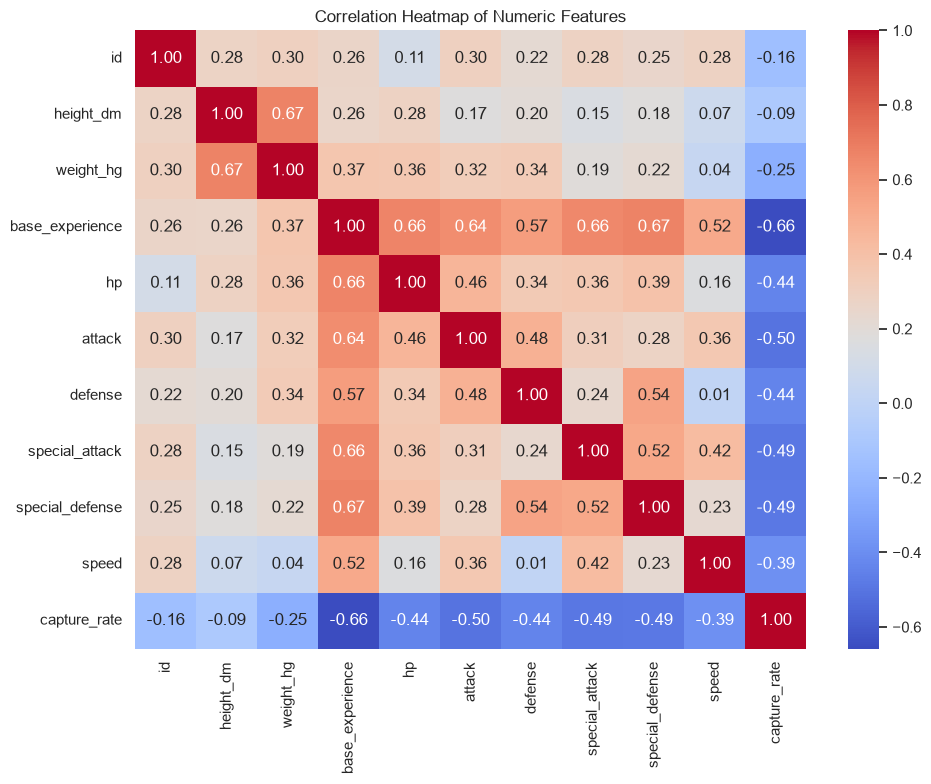

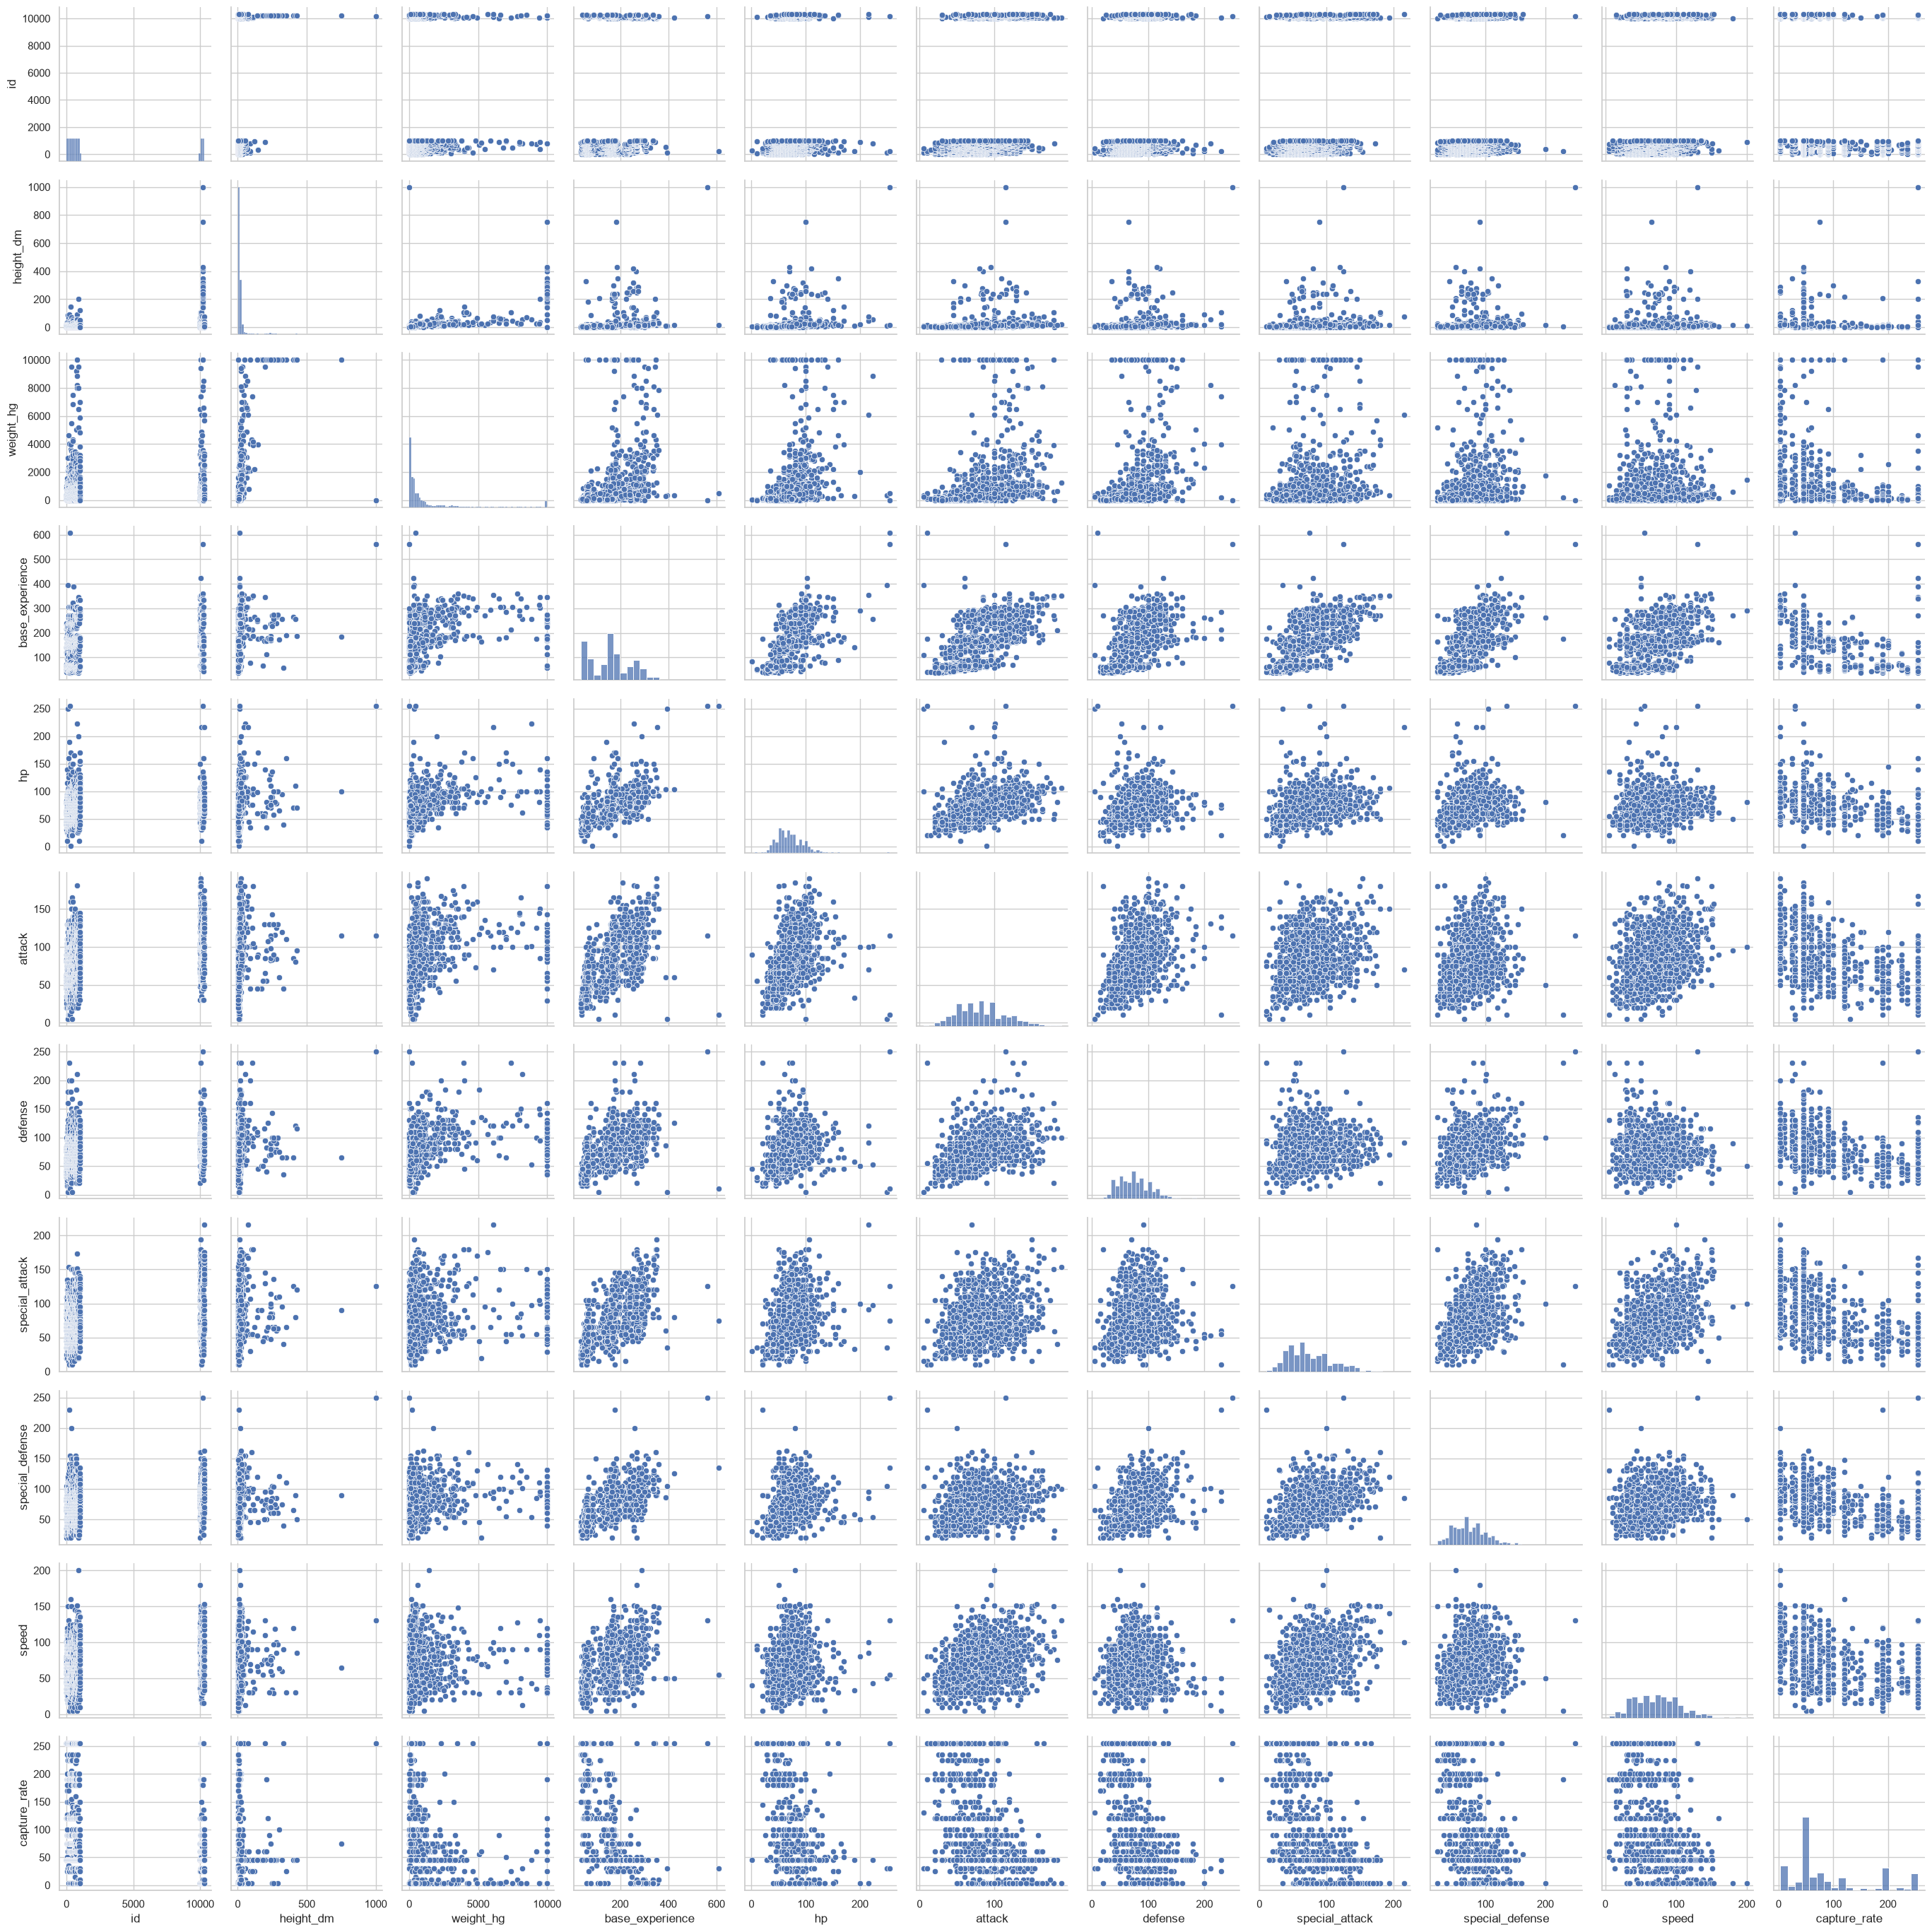

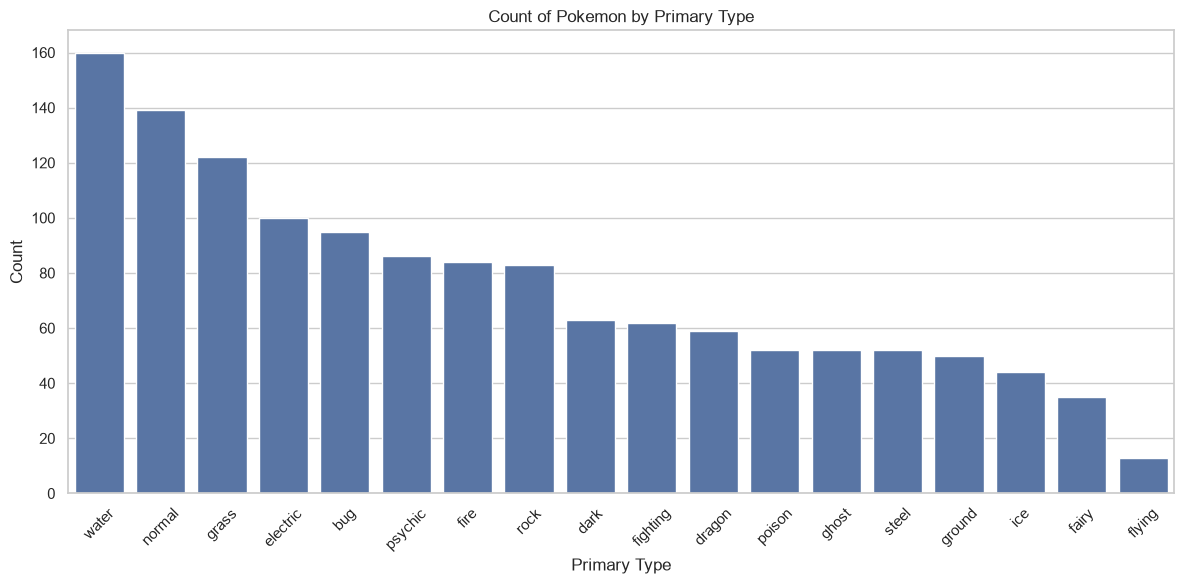

In [10]:
print('DataFrame Info:')
df.info()

print('\nDescriptive Statistics:')
df.describe()

# Visualize distributions of numeric variables if there are enough columns
numeric_df = df.select_dtypes(include=[np.number])

if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(10, 8))
    sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.tight_layout()
    plt.show()

# Create a pair plot to see the pairwise relationships
sns.pairplot(numeric_df)
plt.tight_layout()
plt.show()

# Bar plot for primary Pokemon type counts
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='type_1', order=df['type_1'].value_counts().index)
plt.title('Count of Pokemon by Primary Type')
plt.xlabel('Primary Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
missing_values = df.isnull().sum()
print('Missing values in each column:')
print(missing_values)

# Handling missing values:
# For numeric columns, we impute missing values with the median;
# for categorical columns, we fill missing entries with 'Missing'.

numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
df[categorical_cols] = df[categorical_cols].fillna('Missing')

print('\nAfter imputation, missing values:')
print(df.isnull().sum())

Missing values in each column:
id                   0
name                 0
height_dm            0
weight_hg            0
base_experience     49
type_1               0
type_2             586
hp                   0
attack               0
defense              0
special_attack       0
special_defense      0
speed                0
abilities           14
generation           0
is_legendary         0
is_mythical          0
color                0
shape                0
capture_rate         0
dtype: int64

After imputation, missing values:
id                 0
name               0
height_dm          0
weight_hg          0
base_experience    0
type_1             0
type_2             0
hp                 0
attack             0
defense            0
special_attack     0
special_defense    0
speed              0
abilities          0
generation         0
is_legendary       0
is_mythical        0
color              0
shape              0
capture_rate       0
dtype: int64


Prediction Accuracy: 0.926


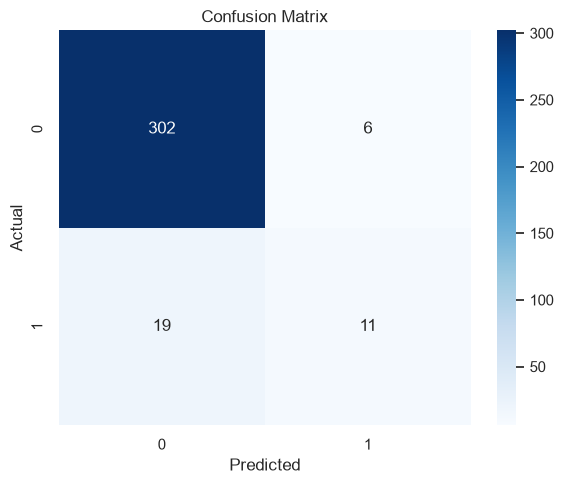

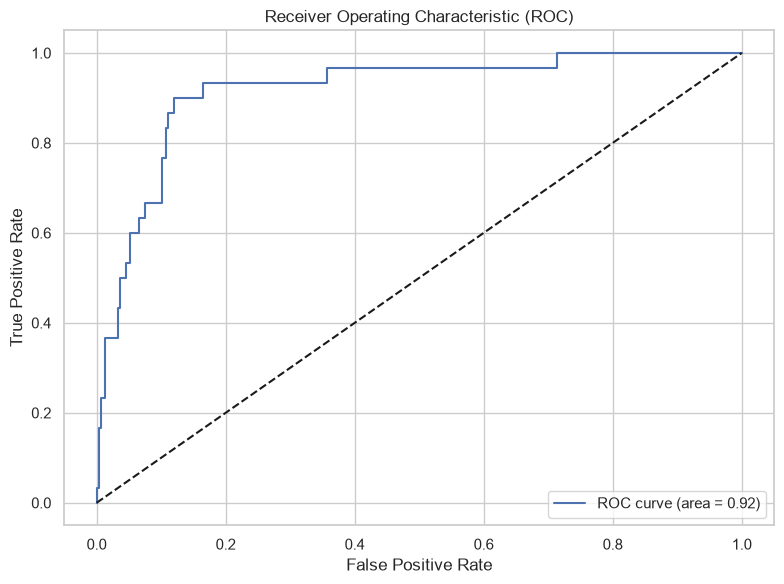

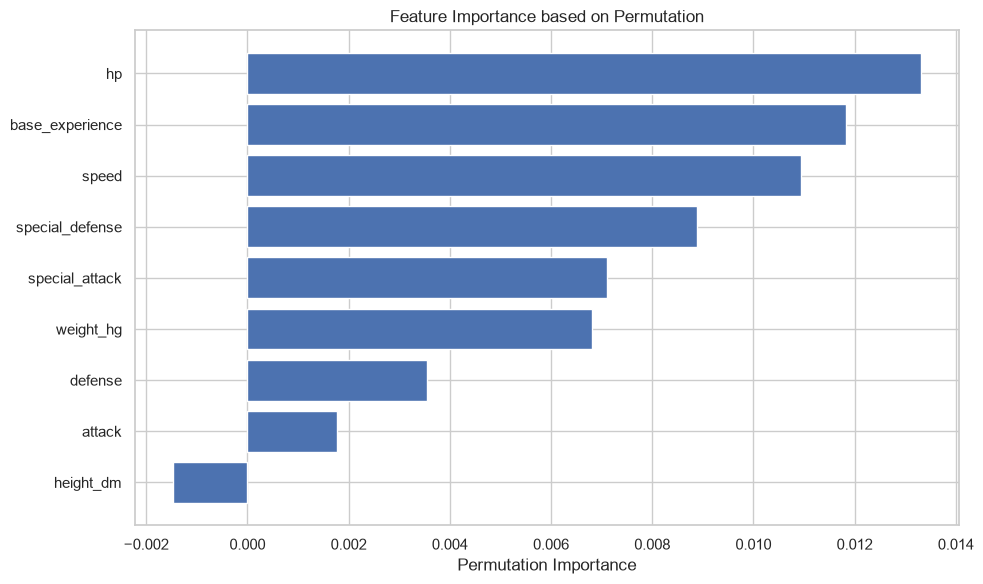

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer

# Define the feature set (only numeric features used for now) and target variable
feature_cols = ['height_dm', 'weight_hg', 'base_experience', 'hp', 
                'attack', 'defense', 'special_attack', 'special_defense', 'speed']

# Ensure that X has no missing values; even though we performed imputation earlier,
# this is an additional safeguard. In more complex scenarios, consider using a pipeline with an imputer.
X = df[feature_cols]
y = df['is_legendary']

# Optionally, one could apply an imputer here (uncomment if needed):
# imputer = SimpleImputer(strategy='median')
# X = pd.DataFrame(imputer.fit_transform(X), columns=feature_cols)

# Split the data into training and testing sets with stratification to preserve the target distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Instantiate and train the logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate and print the prediction accuracy
acc = accuracy_score(y_test, y_pred)
print(f'Prediction Accuracy: {acc:.3f}')

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# ROC Curve Calculation and Visualization
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Permutation Importance for Feature Importance
result = permutation_importance(model, X_test, y_test, scoring='accuracy', n_repeats=10, random_state=42)
sorted_idx = result.importances_mean.argsort()
plt.figure(figsize=(10,6))
plt.barh(np.array(feature_cols)[sorted_idx], result.importances_mean[sorted_idx])
plt.xlabel('Permutation Importance')
plt.title('Feature Importance based on Permutation')
plt.tight_layout()
plt.show()

NameError: name 'save_model' is not defined